# ML Dataset + XGBoost Baseline

Build a per-category training dataset where features summarise the past N days of betting from a panel of high-skill players, and the target is whether each market resolves YES / NO / PASS in the next M days. Save train + test as parquet, then fit an XGBoost classifier as a baseline.

**Prerequisites:** `python update_all.py` has populated `data/trades/` and `data/markets/`.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import os

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

from functools import partial
from poly_data.analysis.io import scan_trades, scan_markets
from poly_data.analysis.io import rss_guard as _rss_guard
# `compute_player_stats` peaks ~12 GB on the full ~163M-trade snapshot
# under polars-streaming. Cap configurable via env for smaller data.
_cap = os.environ.get('POLY_DATA_RSS_CAP_MB', '')
RSS_CAP_MB = int(_cap) if _cap else None  # None = disable assertion
rss_guard = partial(_rss_guard, cap_mb=RSS_CAP_MB)
from poly_data.analysis.positions import compute_player_stats
from poly_data.analysis.ranking import select_top_n, score_C
from poly_data.analysis.ml_dataset import build_dataset, FEATURE_NAMES
from poly_data.analysis.dataloader import load as load_split

DATA_ROOT = Path(os.environ.get('POLY_DATA_ROOT', '../data'))
ML_ROOT = DATA_ROOT / 'ml'
ML_ROOT.mkdir(parents=True, exist_ok=True)

assert (DATA_ROOT / 'trades').is_dir(),  'run `python update_all.py` first'
assert (DATA_ROOT / 'markets').is_dir(), 'run `python update_all.py` first'

trades_lf = scan_trades(DATA_ROOT)
markets_df = scan_markets(DATA_ROOT).collect()
print(f'markets rows: {markets_df.height:,}')

markets rows: 58,986


## Pick the biggest category by # markets

Default metric: number of markets per category (most rows). Override `MEASURE` to use fills or USDC volume.

In [2]:
MEASURE = 'n_markets'   # one of: 'n_markets', 'n_fills', 'usd_volume'

if MEASURE == 'n_markets':
    cat_counts = (markets_df.group_by('category')
                  .agg(pl.len().alias('score'))
                  .sort('score', descending=True))
elif MEASURE == 'n_fills':
    cat_to_market = markets_df.select(['id', 'category']).rename({'id': 'market_id'})
    cat_counts = (trades_lf.join(cat_to_market.lazy(), on='market_id', how='left')
                  .group_by('category').agg(pl.len().alias('score'))
                  .sort('score', descending=True).collect())
else:
    cat_to_market = markets_df.select(['id', 'category']).rename({'id': 'market_id'})
    cat_counts = (trades_lf.join(cat_to_market.lazy(), on='market_id', how='left')
                  .group_by('category').agg(pl.col('usd_amount').sum().alias('score'))
                  .sort('score', descending=True).collect())

print(cat_counts.head(10))
non_empty = cat_counts.filter(pl.col('category') != '')
TARGET_CATEGORY = non_empty['category'][0] if non_empty.height else cat_counts['category'][0]
print(f'\ntarget category: {TARGET_CATEGORY!r}')

shape: (1, 2)
┌──────────┬───────┐
│ category ┆ score │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│          ┆ 58986 │
└──────────┴───────┘

target category: ''


## Compute player stats + select top 128

Pluggable scoring fn. Default `score_C = win_rate * log(max(1, total_won_usd))` with `min_win_rate=0.5`, `min_n_bets=20` filters.

In [3]:
with rss_guard('compute_player_stats'):
    stats = compute_player_stats(trades_lf, player_side='both')

top128 = select_top_n(stats, n=128, min_win_rate=0.5, min_n_bets=20,
                     score_fn=score_C)
print(f'top-128 rows: {top128.height}')
top128.head()

top-128 rows: 128


player,n_won,n_lost,total_won_usd,total_lost_usd,net_usd_pnl,n_bets,win_rate,score_C,score
str,u32,u32,f64,f64,f64,u32,f64,f64,f64
"""0xd218e474776403a330142299f779…",327,1,17119.842373,6886.572713,10233.26966,328,0.996951,9.718274,9.718274
"""0x63d43bbb87f85af03b8f2f9e2fad…",303,1,9261.615653,993.377475,8268.238178,304,0.996711,9.103589,9.103589
"""0xe8dd7741ccb12350957ec71e9ee3…",446,1,7494.624294,838.618289,6656.006005,447,0.997763,8.901982,8.901982
"""0xb48b9192dc52eed724fa58c66fa8…",56,1,7712.230466,6295.473732,1416.756734,57,0.982456,8.793535,8.793535
"""0x9703676286b93c2eca71ca96e875…",84,15,28908.841346,1190.46022,27718.381126,99,0.848485,8.715554,8.715554


## Build dataset (window=7d, horizon=1d) + save

For each `decision_date`, summarise the prior 7 days of top-128 panel activity per market; label by whether the market resolves in the next 1 day (YES / NO / PASS). Filter to markets where at least `ceil(0.5 * 128) = 64` panel members traded in the window. 80/20 train/test split by date.

In [4]:
def slug(c: str) -> str:
    return c.lower().replace(' ', '-').replace('/', '-')

def build_and_save(cat: str, window: int, horizon: int):
    out = ML_ROOT / slug(cat) / f'window={window}d' / f'horizon={horizon}d'
    out.mkdir(parents=True, exist_ok=True)
    with rss_guard(f'build({cat},w={window},h={horizon})'):
        train, test, meta = build_dataset(
            trades_lf, markets_df, top128,
            category=cat, window_days=window, horizon_days=horizon,
            min_active_frac=0.5, test_frac=0.20,
        )
    train.write_parquet(out / 'train.parquet')
    test.write_parquet(out / 'test.parquet')
    top128.write_parquet(out / 'top_n.parquet')
    (out / 'meta.json').write_text(json.dumps(meta, indent=2, default=str))
    return train, test, meta

train7, test7, meta7 = build_and_save(TARGET_CATEGORY, 7, 1)
print('train rows:', meta7['n_train_rows'], 'test rows:', meta7['n_test_rows'])
print('class counts (train):', meta7['target_class_counts_train'])
print('class counts (test): ', meta7['target_class_counts_test'])

train rows: 0 test rows: 0
class counts (train): {'YES': 0, 'NO': 0, 'PASS': 0}
class counts (test):  {'YES': 0, 'NO': 0, 'PASS': 0}


## Build dataset (window=30d, horizon=1d) + save

In [5]:
train30, test30, meta30 = build_and_save(TARGET_CATEGORY, 30, 1)
print('train rows:', meta30['n_train_rows'], 'test rows:', meta30['n_test_rows'])
print('class counts (train):', meta30['target_class_counts_train'])
print('class counts (test): ', meta30['target_class_counts_test'])

train rows: 0 test rows: 0
class counts (train): {'YES': 0, 'NO': 0, 'PASS': 0}
class counts (test):  {'YES': 0, 'NO': 0, 'PASS': 0}


## Class balance — train vs test

Both windows side-by-side. Heavy class imbalance (lots of `PASS`) is expected when the horizon is short relative to typical resolution time.

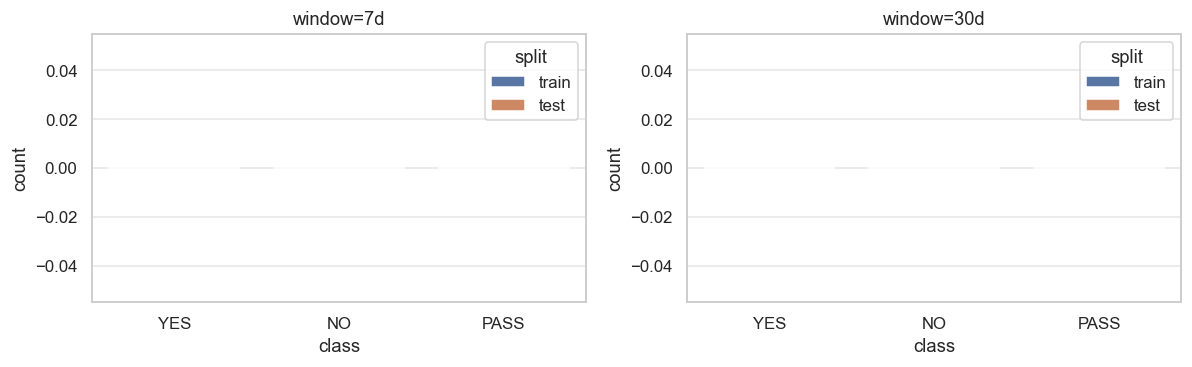

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, meta, label in zip(axes, [meta7, meta30], ['window=7d', 'window=30d']):
    df = pl.DataFrame({
        'class': ['YES', 'NO', 'PASS'] * 2,
        'split': ['train']*3 + ['test']*3,
        'count': [meta['target_class_counts_train'].get(k,0) for k in ('YES','NO','PASS')]
                + [meta['target_class_counts_test'].get(k,0) for k in ('YES','NO','PASS')],
    }).to_pandas()
    sns.barplot(data=df, x='class', y='count', hue='split', ax=ax)
    ax.set_title(label)
plt.tight_layout(); plt.show()

## XGBoost baseline (window=7d)

Histogram-based boosted trees with native NaN handling — no imputation needed. Multiclass log-loss. The baseline is a *floor*; tune later.

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

split = load_split(slug(TARGET_CATEGORY), window_days=7, horizon_days=1, data_root=ML_ROOT)
le = LabelEncoder().fit(['YES', 'NO', 'PASS'])
y_train = le.transform(split.y_train)
y_test  = le.transform(split.y_test)

n_classes_train = len(set(y_train.tolist()))
if n_classes_train < 2:
    print(f'!! train has only {n_classes_train} class — skipping fit. '
          'This typically means the dataset is too small or the horizon is '
          'too short for the chosen window. Increase data span or horizon.')
    clf = None
    pred = None
else:
    clf = xgb.XGBClassifier(
        tree_method='hist', n_estimators=400, max_depth=6,
        learning_rate=0.05, eval_metric='mlogloss',
        n_jobs=4, random_state=0, num_class=len(le.classes_),
    )
    clf.fit(split.X_train, y_train)
    pred = clf.predict(split.X_test)
    if len(y_test) > 0:
        print(classification_report(y_test, pred, target_names=le.classes_, zero_division=0))
    else:
        print('test split is empty')

!! train has only 0 class — skipping fit. This typically means the dataset is too small or the horizon is too short for the chosen window. Increase data span or horizon.


## Confusion matrix + feature importances

In [8]:
if clf is None or pred is None or len(y_test) == 0:
    print('skipping plots — model was not fit (insufficient data)')
else:
    cm = confusion_matrix(y_test, pred, labels=range(len(le.classes_)))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
    axes[0].set_xlabel('predicted'); axes[0].set_ylabel('actual')
    axes[0].set_title('confusion matrix (window=7d)')

    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    axes[1].barh([split.feature_names[i] for i in order],
                 [importances[i] for i in order])
    axes[1].invert_yaxis()
    axes[1].set_title('feature importances')
    plt.tight_layout(); plt.show()

skipping plots — model was not fit (insufficient data)


## Notes

- **Train/test split is strictly temporal** — no leakage. The split date is the 80th percentile of unique decision dates.
- **NaN preserved** in features when a market saw zero buys/sells on a token side in the window — XGBoost handles natively.
- The `window=30d` dataset is saved alongside; rerun `load_split` with `window_days=30` to fit a comparison model.
- For production, swap the criterion (`score_fn=score_money_ratio`, etc.) or change `PLAYER_SIDE` in `compute_player_stats` to study maker- vs taker-only behaviour.